# Mixed-Field Ising Model (MFIM) evolution using Matrix Product Operator (MPO)

with bond dimension χ controlled by operator entanglement.



In [9]:
# using Pkg; Pkg.add("ITensors"); Pkg.add("ITensorMPS"); Pkg.add("LaTeXStrings")

In [14]:
using ITensors, ITensorMPS

using LaTeXStrings
using Plots

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

## MFIM's Hamiltonian

$$H = \sum_j ( X_j X_{j+1} + gX_j + hZ_j ) \quad \text{with} \quad g=1/2, h=1/2$$

In [5]:
g = 0.5
h = 0.5

0.5

---
# 1. Introduction

Before we gonna focus on a simple and controlled setting in order to validate the method and build intuition before moving to more complex circuits and operator.

We consider a system of $N=12$ qubits (particles $1/2$) arranged on a 1D chain. The quantum dynamics is generated by a circuit composed of **two-qubit gates** applied in a **bricklayer pattern**.

In [ ]:
# nombre de spins
N = 8

# creation des sites
sites = ITensors.siteinds("S=1/2", N)

8-element Vector{Index{Int64}}:
 (dim=2|id=916|"S=1/2,Site,n=1")
 (dim=2|id=373|"S=1/2,Site,n=2")
 (dim=2|id=487|"S=1/2,Site,n=3")
 (dim=2|id=933|"S=1/2,Site,n=4")
 (dim=2|id=260|"S=1/2,Site,n=5")
 (dim=2|id=405|"S=1/2,Site,n=6")
 (dim=2|id=789|"S=1/2,Site,n=7")
 (dim=2|id=402|"S=1/2,Site,n=8")

---

# 2. Temporal evolution

In the Heisenberg picture, the evolution applies to the operator.

We will therefore seek here to evolve our operator $\hat{O}$,
which is defined by:

$$\hat{O}(t) = U^{\dagger}\hat{O}U$$

Let us then calculate the evolution operator $U = e^{-iHt}$.

Calculating $U$ for $N$ that is too large is too computationally expensive, we will seek to simplify it by using:

### Trotter decomposition

$$H = \sum_j h_{j,j+1} \quad \text{where} \quad h_{j,j+1} = X_jX_{j+1} +\frac{g}{2}( X_j+X_{j+1})+\frac{h}{2}( Z_j+Z_{j+1})$$

$H$ can be decompose between $j_{odd}$ and $j_{even}$ so $H = H_{odd} + H_{even}$.

We take a small time step $\tau << 1$,
we can use the Baker-Campbell-Hausdorff formula to approximate :

$$U(\tau) = e^{-i \tau H} = e^{-i \tau (H_{odd} + H_{even})} = e^{-i \tau H_o} e^{-i \tau H_e} e^{-i \tau^2 [H_o,H_e]} = e^{-i \tau H_o} e^{-i \tau H_e} + O(\tau^2)$$
because of
$$e^{-i \tau^2 [H_o,H_e]} = \mathbb{I} - i \tau^2 [H_o, H_e] + O(\tau^4) $$

We have an error per time step $\tau$ of order $\tau^2$.

the $h_{j,j+1}$ for $j$ odd or even commute with each other, so

$$e^{-i \tau H_o} = e^{-i \tau \sum_{j_{odd}}h_{j,j+1}} = \prod_{j_{odd}} e^{-i \tau h_{j,j+1}} $$

same for $H_{even}$.

in conclusion we take

$$U^{TEBD2}(\tau) = e^{-iH\tau} \approx \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2} \prod_{j_{even}}e^{-i\tau h_{j,j+1}} \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2}$$

Wich have an error order of $\tau^3$.

Each term: $e^{-i\tau h_{j,j+1}}$ acts only on 2 spins.
Therefore, it can be represented as a 4-index tensor.
This is called a **TEBD gate**.

In [11]:
# Hamiltonien local h_{j,j+1}
function build_two_site_hamiltonian(j::Int64, N::Int64, g::Float64=0.5, h::Float64=0.5)
  s1 = sites[j]
  s2 = sites[j + 1]

  # Terme d'interaction ZZ
  hj = op("X", s1) * op("X", s2)

  # Gestion du champ pour le site de gauche (s1)
  # Si on est au bord gauche (j=1), on met le champ complet, sinon la moitié
  g1 = (j == 1) ? g : g/2
  h1 = (j == 1) ? h : h/2
  hj += g1 * (op("X", s1) * op("Id", s2)) + h1 * (op("Z", s1) * op("Id", s2))

  # Gestion du champ pour le site de droite (s2)
  # Si on est au bord droit (j=N-1), on met le champ complet, sinon la moitié
  g2 = (j == N - 1) ? g : g/2
  h2 = (j == N - 1) ? h : h/2
  hj += g2 * (op("Id", s1) * op("X", s2)) + h2 * (op("Id", s1) * op("Z", s2))

  return hj
end

# Construction des gates TEBD
function build_gates_hj(τ::Float64, N::Int64, g::Float64=0.5, h::Float64=0.5)
  gates_odd = ITensor[]
  gates_even = ITensor[]
  for j in 1:(N-1)
      hj = build_two_site_hamiltonian(j, N, g, h)
      if isodd(j)
        Gj = exp(-im * τ / 2 * hj)
        push!(gates_odd, Gj)
      else
        Gj = exp(-im * τ * hj)
        push!(gates_even, Gj)
      end
  end
  return gates_odd, gates_even
end

function compute_MFIM_circuit(Nqubits::Int64, nlayers::Int64, τ::Float64, g::Float64=0.5, h::Float64=0.5)
  gates_odd, gates_even = build_gates_hj(τ, Nqubits, g, h)

  # On crée une seule liste ordonnée pour un pas de Trotter complet
  # Ordre : Odd (τ/2) -> Even (τ) -> Odd (τ/2)
  one_step_layer = vcat(gates_odd, gates_even, gates_odd)

  return [one_step_layer for _ in 1:nlayers]
end

compute_MFIM_circuit (generic function with 3 methods)

---

# 3. Verification

## 3.1 Evolution of the Identity

If $\hat{O} = \mathbb{I}$ we have :

$$U^\dagger \mathbb{I} U = \mathbb{I} \qquad \forall U \text{ unitary}$$

Let's test the robustness of our method by verifying this result.

In [ ]:
# construction MPO identite
IdMPO = MPO(sites, "Id")

println("Max bond dimension = ", maxlinkdim(IdMPO))

Max bond dimension = 1


max bond dimension $= 1 \implies \chi = 1$, it's the simpliest MPO possible.

In [ ]:
# Truncation
cutoff = 1e-8
maxdim = 500

# Circuit parameters
τ = 0.1
steps = 100

circuit = compute_MFIM_circuit(N, steps, τ, g, h)
ψ0 = MPS(siteinds(first, IdMPO), ["Up" for _ in 1:N]) # |↑↑..↑>

Ot, result_id = mpo.propagate_layerbylayer(circuit, IdMPO; cutoff, maxdim, ψ0)

println("Max bond dimension = ", maxlinkdim(Ot))
println("\nIdentity distance = ", norm(Ot - IdMPO))

layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by mpo_functions.propagate_layerbylayer: 10.519672155380249 seconds
Max bond dimension = 1

Identity distance = 1.249788264800712e-14


This indeed gives the expected result:
$$U^{\dagger}\mathbb{I}U = \mathbb{I}$$
After applying the evolution, we arrive back at the identity, with a **numerical error** of the order of $10^{-14}$ for $100$ steps.

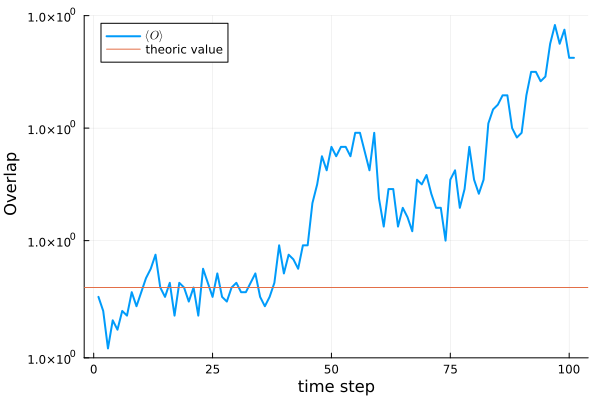

Average Overlap : 1.0000000000000033 ≈ 1


In [ ]:
overlap_values = result_id["overlap"]

p = plot(overlap_values,
     xlabel="time step",
     ylabel="Overlap",
     label=L"\langle O \rangle",
     lw=2)
hline!(p, [1], label="theoric value")
display(p)

import Statistics: mean
println("Average Overlap : ", mean(overlap_values)," ≈ 1")

And the overlap $\langle \uparrow | \mathbb I | \uparrow \rangle \approx 1$.

---

## 3.2 Analytic result

We take a simple case, 2 particules, $H = X_1 X_2$, 150 evolutions's steps with a time discretisation parameter $dt = 0.1$.

In [20]:
nqubits = 2
nlayers = 150
dt = 0.1

# Truncations (we want an exact result)
cutoff = 0.
maxdim = 2^nqubits

# creation des sites, on a besoin de l'init avant le circuit
sites = ITensors.siteinds("S=1/2", nqubits)

# circuit
circuit = compute_MFIM_circuit(nqubits, nlayers, dt, 0.0, 0.0)

# observable
ops = ["Id" for n in 1:nqubits]
ops[1] = "Z"
Z_i = MPO(sites, ops)

# propagation
Z_i_t, result = mpo.propagate_layerbylayer(circuit, Z_i; cutoff, maxdim)
overlap_mpo = result["overlap"]

# Itensor -> matrix
Zitensor = ITensor(1.)
for i = 1:nqubits
  Zitensor *= Z_i_t[i]
end

Z1_t_mpo = Array(Zitensor, sites[2]', sites[1]', sites[2], sites[1])
Z1_t_mpo = reshape(Z1_t_mpo, 4, 4)


layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by mpo_functions.propagate_layerbylayer: 1.6310861110687256 seconds


4×4 Matrix{ComplexF64}:
     0.154251+9.07002e-16im  …   2.47475e-15+0.988032im
 -2.72595e-14+3.59035e-16im     -2.80361e-17-9.99062e-15im
  2.80311e-17-1.40654e-14im      2.39994e-14+4.19336e-16im
  2.67002e-15-0.988032im           -0.154251-9.07007e-16im

Let's compare with the exact result

In [22]:
import LinearAlgebra as la

#------- init matrix -------#
I_mat = ComplexF64[1 0;
                   0 1]
Z = ComplexF64[1  0;
               0 -1]
Y = ComplexF64[0 -1im;
               1im 0]
X = ComplexF64[0 1;
               1 0]

#------- Analytic data -------#
ψ0 = append!([1],[0 for _ in 2:(2^nqubits)])
Z1 = kron(Z, I_mat)
H = kron(X, X)
U = exp(-1im * dt * H) # U = e^{-i * dt * H /2}
U_dagger = U'

overlap_exact = Float64[]
Z1_t_exact = copy(Z1)
push!(overlap_exact, real(ψ0' * Z1_t_exact * ψ0)) # time t=0

for _ in 1:nlayers
    global Z1_t_exact = U_dagger * Z1_t_exact * U
    push!(overlap_exact, real(ψ0' * Z1_t_exact * ψ0))
end

#------- result print -------#
is_close = isapprox(Z1_t_mpo, Z1_t_exact, rtol=1e-5)
println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)

error_val = la.norm(Z1_t_mpo - Z1_t_exact)
println("with an error of :  ", error_val)

Is the analytical calculation close to the Pauli propagation result?  true
with an error of :  7.638817656966092e-14


In [24]:
Z1_t_exact

4×4 Matrix{ComplexF64}:
 0.154251+0.0im            0.0+0.0im       …        0.0+0.988032im
      0.0+0.0im       0.154251+0.0im                0.0+0.0im
      0.0+0.0im            0.0-0.988032im           0.0+0.0im
      0.0-0.988032im       0.0+0.0im          -0.154251+0.0im

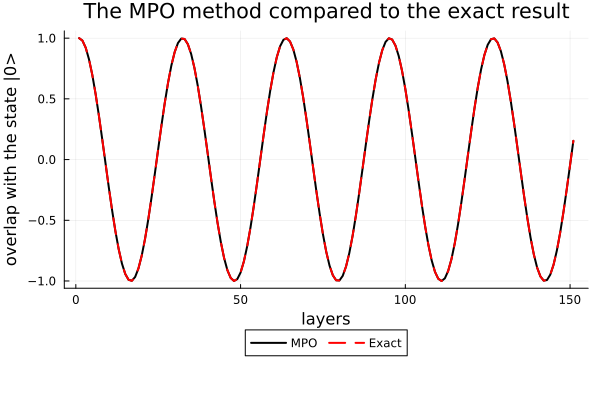

In [23]:
p = plot(title="The MPO method compared to the exact result", xlabel="layers", ylabel="overlap with the state |0>")

plot!(p, overlap_mpo, label="MPO", line = (2, :solid), color=:black)
plot!(p, overlap_exact, label="Exact", line = (2, :dash), color=:red)
plot!(legend=:outerbottom, legendcolumns=2)

display(p)

We obtain the same result, barring a numerical error of $10^{-14}$ with $150$ evolution steps.

---

# 4. Propagation of a local operator

Let's take $\hat{O} = Z_3$ as an example of a local operator.

$$Z_3 = \mathbb{I} \otimes \mathbb{I} \otimes Z \otimes \mathbb{I} \otimes \dots \otimes \mathbb{I}$$


In [ ]:
# Z_3
j = 3

ops = ["Id" for n in 1:N]
ops[j] = "Z"
Z_j = MPO(sites, ops)

println("Max bond dimension = ", maxlinkdim(Z_j))

Max bond dimension = 1


For $Z_3$, we obtain $\chi = 1$ so this is indeed a local operator.

Let's see if the operator propagates correctly through the chain and if it remains local

---

## 4.1 Propagation

we take the bond $N/2$, It is at this index that we separate our system into two parts, and then calculate the entropy between these two blocks.

In [ ]:
# Where we separate the systeme for Operator Entanglement
bond = N÷2

# Truncations
cutoff = 1e-8
maxdim_list = [100, 200, 2^N]

# Circuit parameters
τ = 0.1
steps = 100

circuit = compute_MFIM_circuit(N, steps, τ, g, h)

overlap_values, chi_values, S_values = Vector[], Vector[], Vector[]
for maxdim in maxdim_list
  println("---")
  Z_jt, result = mpo.propagate_layerbylayer(circuit, Z_j; cutoff, maxdim)
  push!(overlap_values, result["overlap"])
  push!(chi_values, result["maxlink"])
  push!(S_values, result["S"])
  println("Max link dimension at the end = ", maxlinkdim(Z_jt))
  println("Max bond dim possible = ", maxdim)
  println("Theorical Max bond dim = ", 2^N) # 2^N = dim max of the matrix
end



---
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 Break cause norm = 15.982423546325514 ≠ 15.999999999999995
Time taken by mpo_functions.propagate_layerbylayer: 21.18758487701416 seconds
Max link dimension at the end = 100
Max bond dim possible = 100
Theorical Max bond dim = 256
---
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by mpo_functions.propagate_layerbylayer: 86.20152497291565 seconds
Max link dimension at the end = 200
Max bond dim possible = 200
Theorical Max bond dim = 256
---
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 comp

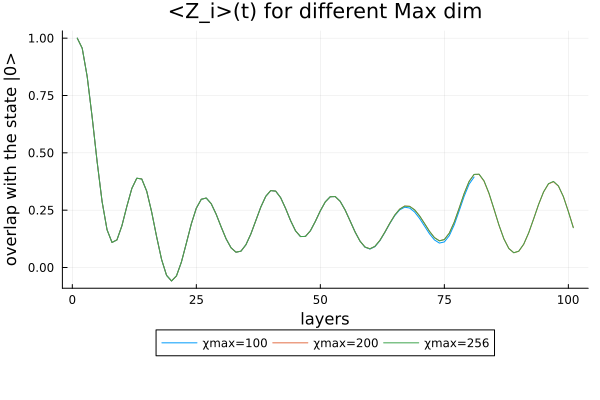

In [ ]:
p = plot(title="<Z_i>(t) for different Max dim", xlabel="layers", ylabel="overlap with the state |0>")
for i in 1:length(maxdim_list)
  plot!(p, 1:length(overlap_values[i]), overlap_values[i], label="χmax=$(maxdim_list[i])")
plot!(legend=:outerbottom, legendcolumns=length(maxdim_list))
end

display(p)

---

## 4.2 Max bond dimenstion ($\chi$)

With the MPO method, we use a cutoff to reduce computation time.
When the max link dimension reaches $2^N$, the max bond dimension, this means either that our system is far too entangled, or that our cutoff is not large enough.

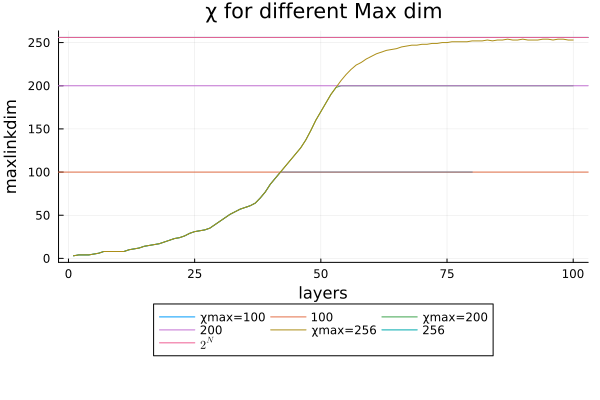

In [ ]:
p = plot(title="χ for different Max dim", xlabel="layers", ylabel="maxlinkdim")
for i in 1:length(maxdim_list)
  plot!(p, 1:length(chi_values[i]), chi_values[i], label="χmax=$(maxdim_list[i])")
  hline!([maxdim_list[i]], label=maxdim_list[i])
end
hline!([2^N], label=L"2^N")
plot!(legend=:outerbottom, legendcolumns=length(maxdim_list))

display(p)

We observe an increase in the maximum bond dimension and a growth in $\chi$ due to operator entanglement caused by $X_jX_{j+1}$ in the Hamiltonian.

The bond dimension $\chi$ measures operator entanglement if the cutoff isn't too large.

---

# 5. Operator Entanglement

If we divide the system into two parts: $A | B$ at idinces `bond` on the spin chain.

We would like to know 'how far' an operator $\hat{O}(t)$ is from a product operator,
$$\hat O \approx O^A \otimes O^B$$

The operator can be rewritten as a matrix:

$$\hat{O} = \sum_\alpha s_\alpha A_\alpha \otimes B_\alpha$$

where:
- $s_\alpha =$  singular values
- $A_\alpha$ acts on A
- $B_\alpha$ acts on B

This is a Schmidt decomposition of the operator.

### Operator Entanglement Entropy

is useful to determine whether an operator can be approximated by a Matrix Product Operator with small bond dimension

$$S_{op} = - \sum_{\alpha } p_\alpha log(p_\alpha)$$

with
$$p_\alpha = \frac{s_\alpha^2}{\sum_\beta s_\beta^2}$$


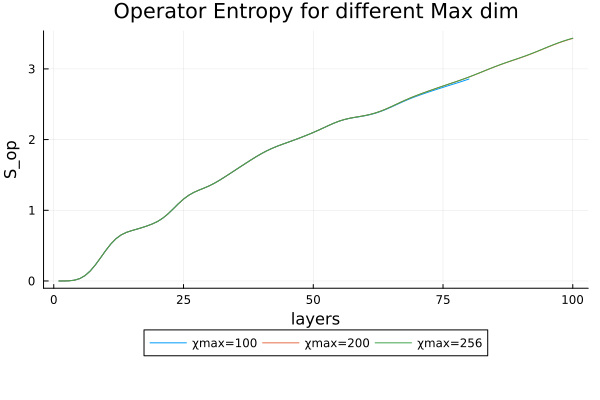

In [ ]:
p = plot(title="Operator Entropy for different Max dim", xlabel="layers", ylabel="S_op")
for i in 1:length(maxdim_list)
  plot!(p, 1:length(S_values[i]), S_values[i], label="χmax=$(maxdim_list[i])")
end
plot!(legend=:outerbottom, legendcolumns=length(maxdim_list))

display(p)

---

$$\chi \approx e^{S_{op}}? $$

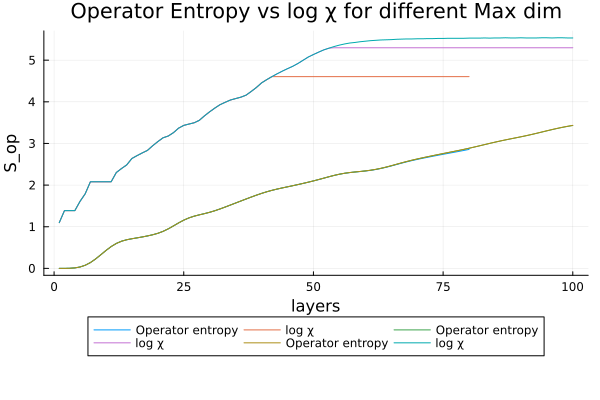

In [ ]:
p = plot(title="Operator Entropy vs log χ for different Max dim", xlabel="layers", ylabel="S_op")
for i in 1:length(maxdim_list)
  plot!(p, S_values[i],
      label="Operator entropy")

  plot!(p, log.(chi_values[i]),
        label="log χ")
end
plot!(legend=:outerbottom, legendcolumns=length(maxdim_list))
display(p)

---

## References

- [Julia documentation](https://docs.julialang.org/en/v1/)
- [ITensor documentation](https://docs.itensor.org/ITensors/stable/index.html)
- https://docs.juliaplots.org/dev/tutorial/
- https://www.phys.ens.psl.eu/~jacobsen/AMP21_Dubail.pdf
- https://tensornetwork.org/mps/algorithms/timeevo/tebd.html